# Simulation Notebook 5

# Scaling profile and benchmark

This notebook is the **only** place where the new JAX implementation is used.

## Notebook structure

1. **Validation against the base implementation** (small/medium sizes):
   - compare training runtime,
   - compare learned coupling matrices,
   - compare attractor retention metrics.
2. **Scaling analysis** (JAX):
   - evaluate runtime trends across larger network sizes,
   - verify that learned attractors remain usable for retrieval.

## Important disclaimer

The JAX implementation uses a parallelized update kernel for efficiency. This is computationally advantageous, but it is **not strictly equivalent** to the original sequential local-update implementation used in the main experiments.

Accordingly, we treat this notebook as a practical scaling and retention study, not as an exact replacement of the core sequential results.

## Hardware specification
The initial scaling demonstration below was performed on a 2022 M3 MAX MacBook Pro with 48Gb Ram, using CPU-only (see Backend policy below).

## Backend policy

This notebook is configured to run on **CPU** (`JAX_PLATFORMS=cpu`). JAX provides only limited GPU support on the used hardware at the time of running these notebooks (7th of March, 2026).

## Backend selection note (CPU vs Apple Metal)

JAX backend is fixed at process initialization. Within one running kernel, you typically cannot safely switch from CPU to METAL on-the-fly. This notebook therefore includes:
- **in-kernel diagnostics** (to show active backend), and
- a **subprocess benchmark** that can test CPU and METAL in separate processes.

In [8]:
# Backend guard: force CPU mode for this notebook.
# NOTE: this must run before importing jax in this kernel.
import os

os.environ["JAX_PLATFORMS"] = "cpu"
os.environ.pop("ENABLE_PJRT_COMPATIBILITY", None)

print("Configured JAX_PLATFORMS=cpu")

Configured JAX_PLATFORMS=cpu


In [9]:
# Ensure subprocess backend benchmark (if used below) defaults to CPU only.
BACKEND_BENCHMARK_MODE = "cpu"

In [10]:
import json
import os
import subprocess
import sys
import time
from copy import deepcopy

import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from simulation.network import AttractorNetwork, Langevin, relax
from simulation.network_jax import JAXAttractorNetwork

### Choosing backend for the main notebook run

The rest of this notebook (validation and scaling sections) runs on the **current kernel backend**.

If you want those sections on METAL, start Jupyter with for example:

`JAX_PLATFORMS=METAL ENABLE_PJRT_COMPATIBILITY=1 jupyter lab`

If you want CPU explicitly:

`JAX_PLATFORMS=cpu jupyter lab`

Use the diagnostics table above to confirm backend availability first.

In [11]:
def normalize_rows(x):
    return (x - x.mean(axis=1, keepdims=True)) / (x.std(axis=1, keepdims=True) + 1e-8)


def make_patterns_gaussian(n_nodes, n_patterns=10, seed=0):
    rng = np.random.default_rng(seed)
    data = rng.normal(size=(n_patterns, n_nodes)).astype(np.float64)
    return normalize_rows(data)

def make_patterns(n_nodes, n_patterns=10, seed=0, sparsity=0.2):
    """Generate unique-ish sparse ternary patterns in {-1, 0, 1}."""
    rng = np.random.default_rng(seed)
    data = np.zeros((n_patterns, n_nodes), dtype=np.float64)

    mask = rng.random((n_patterns, n_nodes)) < sparsity
    signs = rng.choice([-1.0, 1.0], size=(n_patterns, n_nodes))
    data[mask] = signs[mask]

    return data


def _safe_corr(a, b):
    c = np.corrcoef(a, b)[0, 1]
    return 0.0 if np.isnan(c) else float(c)


def train_reference(data, evidence_level=5.0, beta=0.2, lr=0.01, epochs=80, steps=3, seed=0):
    """Train with the original sequential local-update implementation."""
    rng = np.random.default_rng(seed)
    n_nodes = data.shape[1]
    nw = AttractorNetwork(J=np.zeros((n_nodes, n_nodes)), biases=np.zeros(n_nodes), rng=rng)

    t0 = time.perf_counter()
    for _ in range(epochs):
        idx = rng.integers(0, data.shape[0])
        pattern = evidence_level * data[idx]
        for node, b in zip(nw.sigmas, pattern):
            node.bias = b
        for _ in range(steps):
            nw.update(inverse_temperature=beta, learning_rate=lr, least_action=False)
    elapsed = time.perf_counter() - t0
    return nw, nw.get_J(), elapsed


def train_jax(data, evidence_level=5.0, beta=0.2, lr=0.01, epochs=80, steps=3, seed=0):
    """Train with the JAX parallelized implementation (runtime profiling)."""
    n_nodes = data.shape[1]
    jnet = JAXAttractorNetwork(n_nodes=n_nodes, seed=seed)

    # Warm-up for JIT compile so timing reflects execution.
    _ = jnet.train(data, evidence_level=evidence_level, beta=beta, lr=lr, epochs=5, steps=2)
    jax.block_until_ready(jnet.W)

    t0 = time.perf_counter()
    vfe = jnet.train(data, evidence_level=evidence_level, beta=beta, lr=lr, epochs=epochs, steps=steps)
    jax.block_until_ready(vfe)
    elapsed = time.perf_counter() - t0
    return jnet, np.asarray(jnet.W), elapsed, np.asarray(vfe)


def offdiag_corr(a, b):
    n = a.shape[0]
    mask = ~np.eye(n, dtype=bool)
    return np.corrcoef(a[mask], b[mask])[0, 1]


def retention_reference(nw, patterns, infer_beta=100.0, max_steps=150):
    """Retention metric for the reference implementation via deterministic relaxation.

    During inference, the network runs free (no continuous external bias).
    """
    n = patterns.shape[1]
    scores = []
    for p in patterns:
        nw_copy = deepcopy(nw)
        x0 = Langevin(1 * p)
        attractor, _ = relax(
            nw_copy,
            input=x0,
            bias=np.zeros(n),  # free-running inference
            inverse_temperature=infer_beta,
            least_action=True,
            max_steps=max_steps,
            tol=1e-6,
        )
        if np.any(np.isnan(attractor)):
            continue
        scores.append(_safe_corr(attractor, p))
    return float(np.mean(scores)) if scores else np.nan


def retention_jax(jnet, patterns, infer_beta=100.0, steps=150):
    """Retention metric for JAX implementation via deterministic inference.
    Large beta is used to ensure that the deterministic update produces a large number of attractors.
    During inference, the network runs free (no continuous external bias).
    """
    
    n = patterns.shape[1]
    scores = []
    for p in patterns:
        x0 = p # start from the current pattern and relax to an attractor
        acts, _ = jnet.infer(x0=x0, u=np.zeros(n), beta=infer_beta, steps=steps, stochastic=False)
        out = np.asarray(acts[-1])
        scores.append(_safe_corr(out, p)) # is the current pattern an attractor? Or how close is it?
    return float(np.mean(scores))


def noisy_reconstruction_reference(
    nw,
    patterns,
    noise_std=2.0,
    infer_beta=1.0,
    recon_steps=20,
    burn_in=5,
    repeats=1,
    seed=0,
):
    """Noisy-start stochastic reconstruction check for reference implementation.

    During inference, the noisy pattern is continuously presented as bias.
    """
    rng = np.random.default_rng(seed)
    n = patterns.shape[1]
    noisy_corrs = []
    recon_corrs = []
    start_idx = min(max(0, burn_in), max(0, recon_steps - 1))

    for p in patterns:
        for _ in range(repeats):
            noisy = p + rng.normal(0.0, noise_std * np.std(p), size=p.shape)
            noisy_corrs.append(_safe_corr(noisy, p))

            nw_copy = deepcopy(nw)
            for node, b in zip(nw_copy.sigmas, noisy):
                node.bias = float(b)  # continuous noisy cue during inference
            x0 = Langevin(noisy)
            for node, val in zip(nw_copy.sigmas, x0):
                node.activation = float(val)

            acts = []
            for _ in range(recon_steps):
                nw_copy.update(inverse_temperature=infer_beta, learning_rate=0.0, least_action=False)
                acts.append(np.array([node.activation for node in nw_copy.sigmas]))

            acts = np.asarray(acts)
            mean_pattern = acts[start_idx:].mean(axis=0)
            recon_corrs.append(_safe_corr(mean_pattern, p))

    return float(np.mean(noisy_corrs)), float(np.mean(recon_corrs))


def noisy_reconstruction_jax(
    jnet,
    patterns,
    noise_std=2.0,
    infer_beta=1.0,
    recon_steps=20,
    burn_in=5,
    repeats=1,
    seed=0,
):
    """Noisy-start stochastic reconstruction check for JAX implementation.

    During inference, the noisy pattern is continuously presented as bias (u).
    """
    rng = np.random.default_rng(seed)
    n = patterns.shape[1]
    noisy_corrs = []
    recon_corrs = []
    start_idx = min(max(0, burn_in), max(0, recon_steps - 1))

    for p in patterns:
        for _ in range(repeats):
            noisy = p + rng.normal(0.0, noise_std * np.std(p), size=p.shape)
            noisy_corrs.append(_safe_corr(noisy, p))

            x0 = noisy
            acts, _ = jnet.infer(x0=x0, u=noisy, beta=infer_beta, steps=recon_steps, stochastic=True)
            acts = np.asarray(acts)
            mean_pattern = acts[start_idx:].mean(axis=0)
            recon_corrs.append(_safe_corr(mean_pattern, p))

    return float(np.mean(noisy_corrs)), float(np.mean(recon_corrs))

## Part 1 - Validate against the base implementation

In this section we compare base vs JAX on tractable sizes.

For each size we report:
- reference training time,
- JAX training time,
- speedup,
- coupling-matrix similarity,
- attractor retention correlation,
- noisy reconstruction check: correlation of noisy input with original pattern,
- reconstructed (post-relaxation mean pattern) correlation with original pattern.

In [12]:
# Validation settings (kept moderate so the base implementation remains feasible)
validation_sizes = [30, 60, 90, 120]
validation_cfg = {
    "n_patterns": 10,
    "evidence_level": 10.0,
    "beta": 0.5,
    "lr": 0.01,
    "epochs": 200,
    "steps": 5,
    "seed": 11,
    "infer_beta": 1.0,
    "infer_steps": 150,
    "noise_std": 2.0,
    "recon_steps": 20,
    "burn_in": 5,
    "recon_repeats": 1,
}
validation_cfg

{'n_patterns': 10,
 'evidence_level': 10.0,
 'beta': 0.5,
 'lr': 0.01,
 'epochs': 200,
 'steps': 5,
 'seed': 11,
 'infer_beta': 1.0,
 'infer_steps': 150,
 'noise_std': 2.0,
 'recon_steps': 20,
 'burn_in': 5,
 'recon_repeats': 1}

In [13]:
validation_rows = []
validation_artifacts = {}

for n in validation_sizes:
    data = make_patterns(n, n_patterns=validation_cfg["n_patterns"], seed=validation_cfg["seed"] + n)

    nw_ref, J_ref, t_ref = train_reference(
        data,
        evidence_level=validation_cfg["evidence_level"],
        beta=validation_cfg["beta"],
        lr=validation_cfg["lr"],
        epochs=validation_cfg["epochs"],
        steps=validation_cfg["steps"],
        seed=validation_cfg["seed"],
    )

    jnet, J_jax, t_jax, vfe = train_jax(
        data,
        evidence_level=validation_cfg["evidence_level"],
        beta=validation_cfg["beta"],
        lr=validation_cfg["lr"],
        epochs=validation_cfg["epochs"],
        steps=validation_cfg["steps"],
        seed=validation_cfg["seed"],
    )

    rel_fro = np.linalg.norm(J_ref - J_jax) / (np.linalg.norm(J_ref) + 1e-12)
    corr = offdiag_corr(J_ref, J_jax)

    ret_ref = retention_reference(
        nw_ref,
        data,
        infer_beta=validation_cfg["infer_beta"],
        max_steps=validation_cfg["infer_steps"],
    )
    ret_jax = retention_jax(
        jnet,
        data,
        infer_beta=validation_cfg["infer_beta"],
        steps=validation_cfg["infer_steps"],
    )

    # Use noise seeds explicitly offset from pattern-generation seeds.
    noisy_ref, recon_ref = noisy_reconstruction_reference(
        nw_ref,
        data,
        noise_std=validation_cfg["noise_std"],
        infer_beta=validation_cfg["infer_beta"],
        recon_steps=validation_cfg["recon_steps"],
        burn_in=validation_cfg["burn_in"],
        repeats=validation_cfg["recon_repeats"],
        seed=validation_cfg["seed"] + 100_000 + n,
    )
    noisy_jax, recon_jax = noisy_reconstruction_jax(
        jnet,
        data,
        noise_std=validation_cfg["noise_std"],
        infer_beta=validation_cfg["infer_beta"],
        recon_steps=validation_cfg["recon_steps"],
        burn_in=validation_cfg["burn_in"],
        repeats=validation_cfg["recon_repeats"],
        seed=validation_cfg["seed"] + 200_000 + n,
    )

    validation_rows.append(
        {
            "n_nodes": n,
            "reference_train_sec": t_ref,
            "jax_train_sec": t_jax,
            "speedup_ref_over_jax": t_ref / t_jax if t_jax > 0 else np.nan,
            "offdiag_corr_J": corr,
            "relative_frobenius_J_diff": rel_fro,
            "retention_corr_reference": ret_ref,
            "retention_corr_jax": ret_jax,
            "noisy_corr_reference": noisy_ref,
            "reconstructed_corr_reference": recon_ref,
            "noisy_corr_jax": noisy_jax,
            "reconstructed_corr_jax": recon_jax,
            "vfe_start_jax": float(vfe[0]),
            "vfe_end_jax": float(vfe[-1]),
        }
    )

    validation_artifacts[n] = {"J_ref": J_ref, "J_jax": J_jax}

validation_df = pd.DataFrame(validation_rows)
validation_df

,n_nodes,reference_train_sec,jax_train_sec,speedup_ref_over_jax,offdiag_corr_J,relative_frobenius_J_diff,retention_corr_reference,retention_corr_jax,noisy_corr_reference,reconstructed_corr_reference,noisy_corr_jax,reconstructed_corr_jax,vfe_start_jax,vfe_end_jax
0,30,0.684291,0.005849,116.990315,0.814164,0.639197,NaN,0.352065,0.463981,0.514733,0.474375,0.460586,16.221312,14.736393
1,60,2.418410,0.009143,264.507076,0.794706,0.666419,NaN,0.220410,0.431562,0.539404,0.505225,0.496951,22.617144,12.572913
2,90,5.699815,0.016793,339.416119,0.739789,0.750940,0.321111,0.290952,0.473250,0.556961,0.490323,0.541895,27.683809,23.895796
3,120,10.288229,0.025234,407.716338,0.661923,0.876440,0.126527,0.119454,0.473844,0.491301,0.435551,0.458793,52.220650,37.999981


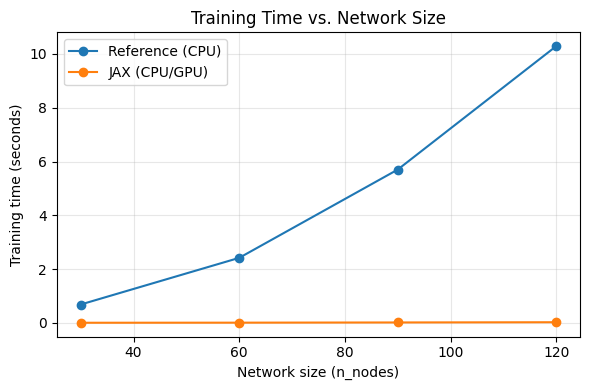

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(validation_df["n_nodes"], validation_df["reference_train_sec"], '-o', label="Reference (CPU)")
plt.plot(validation_df["n_nodes"], validation_df["jax_train_sec"], '-o', label="JAX (CPU/GPU)")
plt.xlabel("Network size (n_nodes)")
plt.ylabel("Training time (seconds)")
plt.title("Training Time vs. Network Size")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


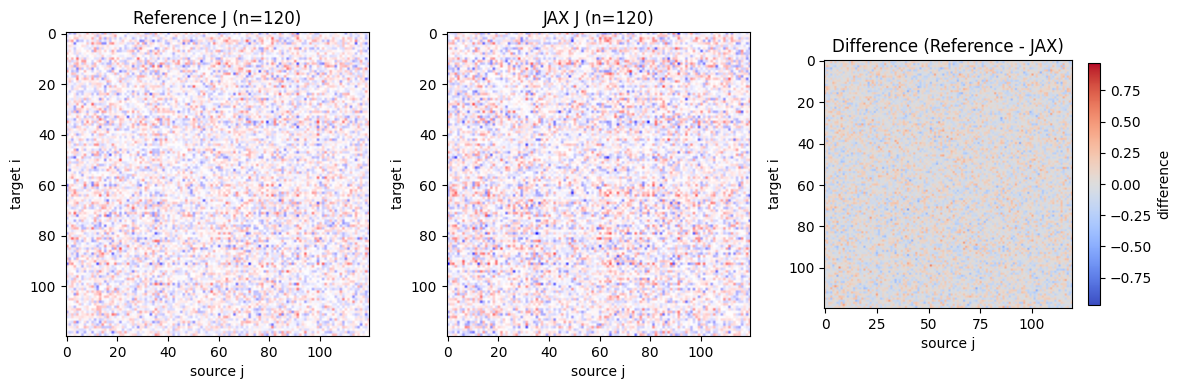

In [16]:
# Visualize coupling comparison for the largest validation size
n_show = max(validation_sizes)
J_ref = validation_artifacts[n_show]["J_ref"]
J_jax = validation_artifacts[n_show]["J_jax"]
vmax = np.max(np.abs(np.concatenate([J_ref.ravel(), J_jax.ravel()])))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
im0 = axes[0].imshow(J_ref, cmap="bwr", vmin=-vmax, vmax=vmax)
axes[0].set_title(f"Reference J (n={n_show})")
axes[0].set_xlabel("source j")
axes[0].set_ylabel("target i")

im1 = axes[1].imshow(J_jax, cmap="bwr", vmin=-vmax, vmax=vmax)
axes[1].set_title(f"JAX J (n={n_show})")
axes[1].set_xlabel("source j")
axes[1].set_ylabel("target i")

im2 = axes[2].imshow(J_ref - J_jax, cmap="coolwarm", vmin=-vmax, vmax=vmax)
axes[2].set_title("Difference (Reference - JAX)")
axes[2].set_xlabel("source j")
axes[2].set_ylabel("target i")

#fig.colorbar(im1, ax=axes[:2], shrink=0.8, label="coupling")
fig.colorbar(im2, ax=axes[2], shrink=0.8, label="difference")
plt.tight_layout()
plt.show()

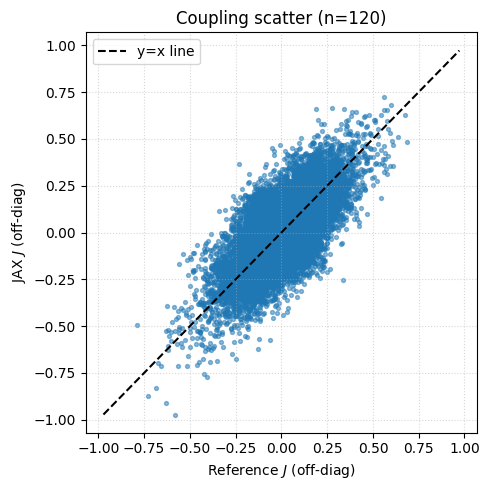

In [17]:
# Scatter plot: J_ref vs J_jax (flattened, off-diagonal only)
import matplotlib.pyplot as plt
import numpy as np

# Create boolean mask for off-diagonal elements
n = J_ref.shape[0]
offdiag_mask = ~np.eye(n, dtype=bool)

J_ref_flat = J_ref[offdiag_mask]
J_jax_flat = J_jax[offdiag_mask]

plt.figure(figsize=(5,5))
plt.scatter(J_ref_flat, J_jax_flat, alpha=0.5, s=8)
lim = max(abs(J_ref_flat).max(), abs(J_jax_flat).max())
plt.plot([-lim, lim], [-lim, lim], "k--", label="y=x line")
plt.xlabel("Reference $J$ (off-diag)")
plt.ylabel("JAX $J$ (off-diag)")
plt.title(f"Coupling scatter (n={n_show})")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

## Part 2 - How much can we scale while retaining attractors?

Now we run a JAX-only scaling sweep (larger sizes) and monitor:
- training time,
- throughput (steps/sec),
- attractor retention correlation,
- noisy reconstruction check (noisy vs original and reconstructed vs original correlations).

Noisy reconstruction uses stochastic relaxation for a fixed number of steps, then averages activity after a short burn-in period.

### First, let's profile runtimes.

In [25]:
# Scaling settings
scaling_sizes = [100, 1000, 5000, 10000, 20000, 50000]
scaling_cfg = {
    "pattern_counts": 20,
    "sparsity": 1.0,
    "repeats": 1,
    "evidence_level": 2.0,
    "beta": 1.0,
    "lr": 0.001,
    "epochs": 10,
    "steps": 1,
    "seed": 101,
}

In [26]:
scaling_rows = []

for n in scaling_sizes:
    data = make_patterns(n, n_patterns=scaling_cfg["pattern_counts"], seed=scaling_cfg["seed"] + n)

    jnet, J_jax, t_jax, vfe = train_jax(
        data,
        evidence_level=scaling_cfg["evidence_level"],
        beta=scaling_cfg["beta"],
        lr=scaling_cfg["lr"],
        epochs=scaling_cfg["epochs"],
        steps=scaling_cfg["steps"],
        seed=scaling_cfg["seed"],
    )

    scaling_rows.append(
        {
            "n_nodes": n,
            "jax_train_sec": t_jax,
            "jax_steps_per_sec": (scaling_cfg["epochs"] * scaling_cfg["steps"]) / t_jax
        }
    )

scaling_df = pd.DataFrame(scaling_rows)
scaling_df

,n_nodes,jax_train_sec,jax_steps_per_sec
0,100,0.004074,2454.740861
1,1000,0.007197,1389.524188
2,5000,0.255493,39.140028
3,10000,0.391749,25.526549
4,20000,1.493999,6.693446
5,50000,59.847521,0.167091


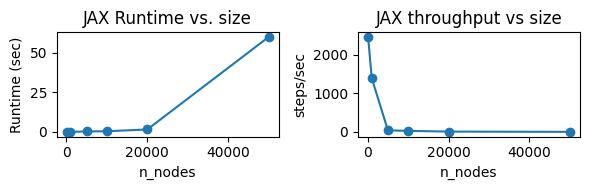

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(6, 2))

axes[0].plot(scaling_df["n_nodes"], scaling_df["jax_train_sec"], marker="o")
axes[0].set_title("JAX Runtime vs. size")
axes[0].set_xlabel("n_nodes")
axes[0].set_ylabel("Runtime (sec)")

axes[1].plot(scaling_df["n_nodes"], scaling_df["jax_steps_per_sec"], marker="o")
axes[1].set_title("JAX throughput vs size")
axes[1].set_xlabel("n_nodes")
axes[1].set_ylabel("steps/sec")


plt.tight_layout()
plt.savefig('fig/runtimes.pdf', dpi=300)
plt.show()

## Part 3 - Storage capacity (quality vs number of stored patterns)

This section probes storage capacity by varying how many patterns are stored in a fixed-size network, then measuring both retention and noisy reconstruction quality.

**Protocol**
- keep network size fixed,
- vary number of patterns,
- train with the same update settings,
- compute mean retention correlation,
- compute noisy reconstruction correlations (noisy vs original, reconstructed mean vs original).

A decreasing quality curve with increasing pattern count is expected; the key question is where degradation becomes substantial.

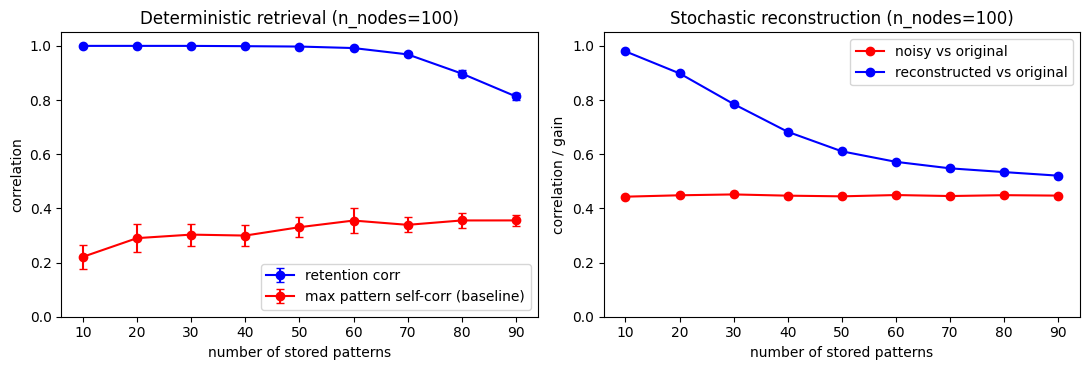

,n_patterns,retention_mean,retention_std,noisy_corr_mean,reconstructed_corr_mean,reconstruction_gain_mean,train_sec_mean,data_max_corr_mean,data_max_corr_std
0,10,1.000000,8.183213e-10,0.443224,0.979765,0.536540,1.862323,0.221134,0.044939
1,20,1.000000,1.045651e-09,0.448362,0.898457,0.450095,1.889084,0.290164,0.051891
2,30,0.999934,2.038994e-04,0.451526,0.785230,0.333704,1.902263,0.303145,0.040470
3,40,0.998900,1.006793e-03,0.446954,0.682731,0.235777,1.870445,0.299664,0.038153
4,50,0.997519,7.756099e-04,0.444490,0.610624,0.166133,1.890543,0.330516,0.036330
5,60,0.991946,2.553668e-03,0.449249,0.571798,0.122548,1.895536,0.355063,0.045112
6,70,0.968615,7.130038e-03,0.445626,0.547847,0.102221,1.888798,0.339230,0.027493
7,80,0.897834,1.357491e-02,0.448773,0.533979,0.085205,1.910237,0.355436,0.028930
8,90,0.813377,1.422015e-02,0.447160,0.520772,0.073611,1.926641,0.355573,0.021298


In [37]:
# Storage-capacity experiment settings
capacity_cfg = {
    "n_nodes": 100,
    "pattern_counts": [10, 20, 30, 40, 50, 60, 70, 80, 90],
    "sparsity": 1.0,
    "repeats": 20,
    "evidence_level": 2.0,
    "beta": 1.0,
    "lr": 0.0005,
    "epochs": 10000,
    "steps": 10,
    "infer_beta": 1.0,
    "infer_steps": 200,
    "noise_std": 2.0,
    "recon_steps": 20,
    "burn_in": 0,
    "recon_repeats": 1,
    "seed": 101,
}
capacity_rows = []

for pcount in capacity_cfg["pattern_counts"]:
    for rep in range(capacity_cfg["repeats"]):
        data = make_patterns(
            capacity_cfg["n_nodes"],
            n_patterns=pcount,
            seed=capacity_cfg["seed"] + 1000 * rep + pcount,
            sparsity=capacity_cfg["sparsity"],
        )

        jnet, J_jax, t_jax, vfe = train_jax(
            data,
            evidence_level=capacity_cfg["evidence_level"],
            beta=capacity_cfg["beta"],
            lr=capacity_cfg["lr"],
            epochs=capacity_cfg["epochs"],
            steps=capacity_cfg["steps"],
            seed=capacity_cfg["seed"] + rep,
        )

        #retention = 0.0
        retention = retention_jax(
            jnet,
            data,
            steps=capacity_cfg["infer_steps"],
        )

        noisy_corr, recon_corr = noisy_reconstruction_jax(
            jnet,
            data,
            noise_std=capacity_cfg["noise_std"],
            infer_beta=capacity_cfg["beta"], # same beta as for training
            recon_steps=capacity_cfg["recon_steps"],
            burn_in=capacity_cfg["burn_in"],
            repeats=capacity_cfg["recon_repeats"],
            seed=capacity_cfg["seed"] + 400_000 + 1000 * rep + pcount,
        )

        corr = np.corrcoef(data)
        capacity_rows.append(
            {
                "n_nodes": capacity_cfg["n_nodes"],
                "n_patterns": pcount,
                "sparsity": capacity_cfg["sparsity"],
                "data_max_corr": np.max(corr[np.triu_indices_from(corr, k=1)]),
                "repeat": rep,
                "retention_corr_jax": retention,
                "noisy_corr_jax": noisy_corr,
                "reconstructed_corr_jax": recon_corr,
                "reconstruction_gain_jax": recon_corr - noisy_corr,
                "jax_train_sec": t_jax,
                "vfe_start_jax": float(vfe[0]),
                "vfe_end_jax": float(vfe[-1]),
            }
        )

capacity_df = pd.DataFrame(capacity_rows)
capacity_summary = (
    capacity_df.groupby("n_patterns", as_index=False)
    .agg(
        retention_mean=("retention_corr_jax", "mean"),
        retention_std=("retention_corr_jax", "std"),
        noisy_corr_mean=("noisy_corr_jax", "mean"),
        reconstructed_corr_mean=("reconstructed_corr_jax", "mean"),
        reconstruction_gain_mean=("reconstruction_gain_jax", "mean"),
        train_sec_mean=("jax_train_sec", "mean"),
        data_max_corr_mean=("data_max_corr", "mean"),
        data_max_corr_std=("data_max_corr", "std"),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# Left: deterministic retrieval capacity
axes[0].errorbar(
    capacity_summary["n_patterns"],
    capacity_summary["retention_mean"],
    yerr=capacity_summary["retention_std"].fillna(0.0),
    color="Blue",
    marker="o",
    capsize=3,
    label="retention corr",
)

axes[0].errorbar(
    capacity_summary["n_patterns"],
    capacity_summary["data_max_corr_mean"],
    yerr=capacity_summary["data_max_corr_std"].fillna(0.0),
    color="Red",
    marker="o",
    capsize=3,
    label="max pattern self-corr (baseline)",
)

axes[0].set_ylim(0.0, 1.05)
axes[0].set_xlabel("number of stored patterns")
axes[0].set_ylabel("correlation")
axes[0].set_title(f"Deterministic retrieval (n_nodes={capacity_cfg['n_nodes']})")
axes[0].legend()

# Right: stochastic reconstruction capacity
axes[1].plot(
    capacity_summary["n_patterns"],
    capacity_summary["noisy_corr_mean"],
     marker="o",
    color="Red",
    label="noisy vs original",
)
axes[1].plot(
    capacity_summary["n_patterns"],
    capacity_summary["reconstructed_corr_mean"],
    color="Blue",
    marker="o",
    label="reconstructed vs original",
)
#axes[1].plot(
#    capacity_summary["n_patterns"],
#    capacity_summary["reconstruction_gain_mean"],
#    color="Green",
#    marker="o",
#    label="reconstruction gain",
#)
axes[1].set_ylim(0.0, 1.05)
axes[1].set_xlabel("number of stored patterns")
axes[1].set_ylabel("correlation / gain")
axes[1].set_title(f"Stochastic reconstruction (n_nodes={capacity_cfg['n_nodes']})")
axes[1].legend()

plt.tight_layout()
plt.show()

capacity_summary


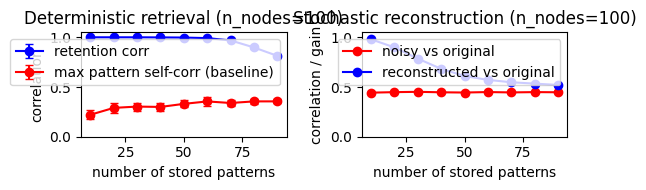

,n_patterns,retention_mean,retention_std,noisy_corr_mean,reconstructed_corr_mean,reconstruction_gain_mean,train_sec_mean,data_max_corr_mean,data_max_corr_std
0,10,1.000000,8.183213e-10,0.443224,0.979765,0.536540,1.889391,0.221134,0.044939
1,20,1.000000,1.045651e-09,0.448362,0.898457,0.450095,1.865265,0.290164,0.051891
2,30,0.999934,2.038994e-04,0.451526,0.785230,0.333704,1.883773,0.303145,0.040470
3,40,0.998900,1.006793e-03,0.446954,0.682731,0.235777,1.932929,0.299664,0.038153
4,50,0.997519,7.756099e-04,0.444490,0.610624,0.166133,1.908353,0.330516,0.036330
5,60,0.991946,2.553668e-03,0.449249,0.571798,0.122548,1.896267,0.355063,0.045112
6,70,0.968615,7.130038e-03,0.445626,0.547847,0.102221,1.935344,0.339230,0.027493
7,80,0.897834,1.357491e-02,0.448773,0.533979,0.085205,1.932085,0.355436,0.028930
8,90,0.813377,1.422015e-02,0.447160,0.520772,0.073611,1.950435,0.355573,0.021298


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(6, 2))

# Left: deterministic retrieval capacity
axes[0].errorbar(
    capacity_summary["n_patterns"],
    capacity_summary["retention_mean"],
    yerr=capacity_summary["retention_std"].fillna(0.0),
    color="Blue",
    marker="o",
    capsize=3,
    label="retention corr",
)

axes[0].errorbar(
    capacity_summary["n_patterns"],
    capacity_summary["data_max_corr_mean"],
    yerr=capacity_summary["data_max_corr_std"].fillna(0.0),
    color="Red",
    marker="o",
    capsize=3,
    label="max pattern self-corr (baseline)",
)

axes[0].set_ylim(0.0, 1.05)
axes[0].set_xlabel("number of stored patterns")
axes[0].set_ylabel("correlation")
axes[0].set_title(f"Deterministic retrieval (n_nodes={capacity_cfg['n_nodes']})")
axes[0].legend()

# Right: stochastic reconstruction capacity
axes[1].plot(
    capacity_summary["n_patterns"],
    capacity_summary["noisy_corr_mean"],
     marker="o",
    color="Red",
    label="noisy vs original",
)
axes[1].plot(
    capacity_summary["n_patterns"],
    capacity_summary["reconstructed_corr_mean"],
    color="Blue",
    marker="o",
    label="reconstructed vs original",
)
#axes[1].plot(
#    capacity_summary["n_patterns"],
#    capacity_summary["reconstruction_gain_mean"],
#    color="Green",
#    marker="o",
#    label="reconstruction gain",
#)
axes[1].set_ylim(0.0, 1.05)
axes[1].set_xlabel("number of stored patterns")
axes[1].set_ylabel("correlation / gain")
axes[1].set_title(f"Stochastic reconstruction (n_nodes={capacity_cfg['n_nodes']})")
axes[1].legend()

plt.tight_layout()
plt.savefig('fig/storage.pdf', dpi=300)
plt.show()

capacity_summary
